In [1]:
%cd /home/andreasstillits/coding/Leaves1D/PNAS_REVIEW

/home/andreasstillits/coding/Leaves1D/PNAS_REVIEW


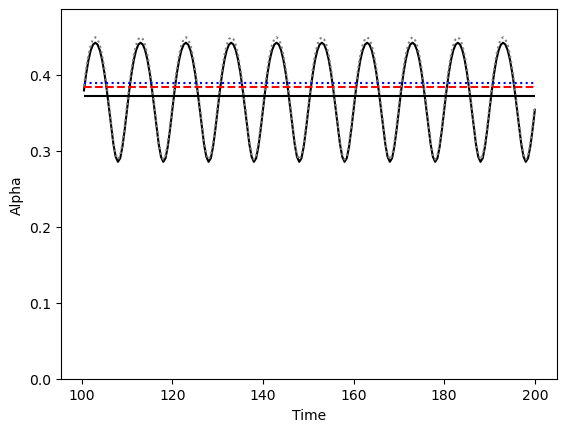

Relative difference mean-hom: 0.0453
Relative difference mean-het: 0.0302
Mean alpha: 0.3722, Homogeneous alpha: 0.3891, Heterogeneous alpha: 0.3835


In [3]:
from review.temporal.solver import TemporalSolver 
from review.steady.solver import SteadySolver 
from review.utils.profiles import StepProfile, OscillatorProfile 
from review.utils.homogeneous import homogeneous_solution
import matplotlib.pyplot as plt
import numpy as np

periods_to_run = 20 
periods_to_cut = 10
fraction_of_period = 0.05 

params = [1, 1, 0.1] # tau, gamma, chi_ 
rho = [0.5, 0.5, 0.6] # rhoD, rhoK, rhoL 

amplitude = 0.50
period = 10 
timing = [0, periods_to_run * period, fraction_of_period * period] # t0, tf, dt

delta = StepProfile(direction="down") 
delta.populate_rho(rho[0], rho[2])
kappa = StepProfile(direction="up")
kappa.populate_rho(rho[1], rho[2])
osc = OscillatorProfile(amplitude, period) 

tsolver = TemporalSolver(params, timing=timing, 
                         update_delta=delta.generalize(),
                         update_kappa=kappa.generalize(),
                         update_stomata=osc.generalize())
times, alphas = tsolver.solve() 
idx = int(len(alphas) * periods_to_cut / periods_to_run)
times, alphas = times[idx:], alphas[idx:]

tsolver_hom = TemporalSolver(params, timing=timing, update_stomata=osc.generalize())
times_hom, alphas_hom = tsolver_hom.solve()
times_hom, alphas_hom = times_hom[idx:], alphas_hom[idx:]

alpha_mean = np.mean(alphas)
tmin, tmax = np.min(times), np.max(times)

ssolver = SteadySolver(params, display=True, display_name="notebooks/ss_profile.png",
                       delta=delta.steadify(), kappa=kappa.steadify())
domain, solution = ssolver.solve()
alpha_het = params[1] * (1 - solution[0])
alpha_hom = params[1] * (1 - homogeneous_solution(0, params))

plt.plot(times, alphas, "k-")
plt.plot(times_hom, alphas_hom, color="grey", linestyle=":")
plt.hlines(alpha_mean, tmin, tmax, colors="k", linestyles="-")
plt.hlines(alpha_het, tmin, tmax, colors="r", linestyles="--")
plt.hlines(alpha_hom, tmin, tmax, colors="b", linestyles=":")
plt.xlabel("Time")
plt.ylabel("Alpha")
plt.ylim(0, np.max([alphas.max(), alpha_het, alpha_hom])*1.1)
plt.show()
print(f"Relative difference mean-hom: {np.abs(alpha_hom - alpha_mean) / alpha_mean:.4f}")
print(f"Relative difference mean-het: {np.abs(alpha_het - alpha_mean) / alpha_mean:.4f}")
print(f"Mean alpha: {alpha_mean:.4f}, Homogeneous alpha: {alpha_hom:.4f}, Heterogeneous alpha: {alpha_het:.4f}")